# Lab 05: The Dark Companion, Two Years Later

**ASTR 457, Fall 2026, posted Sat Oct 3, due Fri Oct 9 by Noon (extended) (fork → PR, as always)**

*Why this lab: every orbit in the literature, from Gaia's black-hole binaries to the planets David Charbonneau talked about on Tuesday, is a posterior distribution over six or seven parameters that nobody can write down in closed form. Sampling it, knowing when the sampler has actually converged, and turning the samples into a number with an honest error bar is the core professional skill of modern astrophysics, and the place where confident, fluent, wrong analyses are most common.*

On Day 1 you watched a star's radial velocity drift over ten nights and inferred an unseen companion from
the slope alone. This is that programme, two and a half years on. Every one of you has your own star:
`data/<your netid>.csv`, with columns `t_days` (time of each spectrum, from the first epoch), `rv_kms`
(the measured radial velocity) and `sigma_rv_kms` (the pipeline's per-epoch uncertainty). The star was
observed in three observing seasons over about 900 days, 28 to 44 epochs in all. It is a **single-lined
spectroscopic binary**: you see one star's lines, the companion contributes no light, and the visible star
follows a Keplerian orbit,

$$v_r(t) = \gamma + K\left[\cos\big(\nu(t) + \omega\big) + e\cos\omega\right],$$

with period $P$, semi-amplitude $K$, eccentricity $e$, argument of periastron $\omega$, a time of periastron
$T_p$, systemic velocity $\gamma$, and $\nu(t)$ the true anomaly (the angle around the orbit, which you get
from Kepler's equation; a function is provided). What you are really after is the **mass function**

$$f(M) = \frac{P K^3 (1 - e^2)^{3/2}}{2\pi G} = \frac{M_2^3 \sin^3 i}{(M_1 + M_2)^2},$$

a lower limit on the companion's mass, in solar masses. If it comes out above about $3\,M_\odot$ for a
Sun-like primary, you have a black hole candidate, the way Gaia BH1 was found (El-Badry et al. 2023, the Sep 8
colloquium). In the units of your file, $f(M) = 1.0361\times10^{-7}\,(1-e^2)^{3/2} K^3 P$ with $K$ in km/s
and $P$ in days.

I know your true $P$, $K$, $e$ and $f(M)$. You don't, your classmates' stars are different, and so is the
sampling. **One more thing I know and you don't: the quoted `sigma_rv_kms` is not the whole error.** Real
radial velocities carry an extra scatter, called jitter, from the star's own surface and from template
mismatch, and it is not in the pipeline number.

**How this is graded.** As always, on whether your answers are *right* and your uncertainties are *honest*:
your reported $P$, $K$, $e$ and $f(M)$ are compared to your truth in units of your own reported uncertainty.
Anti-sandbagging cap: your $\sigma_K$ may not exceed $3\times$ a reference posterior width I compute for your
dataset. Padded error bars lose points like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document it in Part 4. You
may be selected to defend this lab orally; the defense is easy if you did the work.

Weights: Part 1 15%, Part 2 40%, Part 3 35%, Part 4 10%.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.optimize import minimize
from astropy.timeseries import LombScargle

NETID = 'ahuwer2'   # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
t, rv, sig = d['t_days'], d['rv_kms'], d['sigma_rv_kms']
print(f"{t.size} epochs over {t.max() - t.min():.0f} days; median quoted error {np.median(sig):.2f} km/s")

def kepler_rv(t, P, K, e, omega, Tp, gamma):
    """Radial velocity of the visible star in a Keplerian orbit.
    P period [d], K semi-amplitude [km/s], e eccentricity, omega argument of periastron [rad],
    Tp a time of periastron [d], gamma systemic velocity [km/s]. Solves Kepler's equation by Newton iteration."""
    M = 2. * np.pi * ((t - Tp) / P % 1.0)            # mean anomaly
    E = M.copy()                                     # eccentric anomaly
    for _ in range(30):
        E = E - (E - e * np.sin(E) - M) / (1. - e * np.cos(E))
    nu = 2. * np.arctan2(np.sqrt(1. + e) * np.sin(E / 2.), np.sqrt(1. - e) * np.cos(E / 2.))   # true anomaly
    return gamma + K * (np.cos(nu + omega) + e * np.cos(omega))

def mass_function(P, K, e):
    """f(M) in solar masses, for P in days and K in km/s."""
    return 1.0361e-7 * (1. - e**2)**1.5 * K**3 * P

34 epochs over 854 days; median quoted error 1.62 km/s


## Part 1: Look first, then find the period (15%)

Plot the radial velocities against time with their error bars. Then find candidate orbital periods with a
Lomb-Scargle periodogram of the velocities (`astropy.timeseries.LombScargle`, Day 7's periodogram, formally
taught on Oct 20/22; for now it is a tool that ranks periods). Plot the periodogram. Then, for the best two or
three candidate periods, phase-fold the data and look.

Answer, in a few sentences: how many candidate periods are plausible from the periodogram alone, and why does
a Lomb-Scargle periodogram (which fits a *sinusoid*) not settle the question for an eccentric orbit? What
feature of the sampling (look at the gaps) produces the other peaks?


Times between measurements:
[  7.125   2.828   0.825  15.019   0.38   13.653  30.998   6.213  56.488
  17.429  16.995 182.6     3.325   6.153   1.062   8.558   3.9    33.423
  34.299  49.047   7.182   8.776 189.418  13.697  19.447  23.156   1.397
  55.878   0.907  11.457  14.105   9.063   8.83 ] days


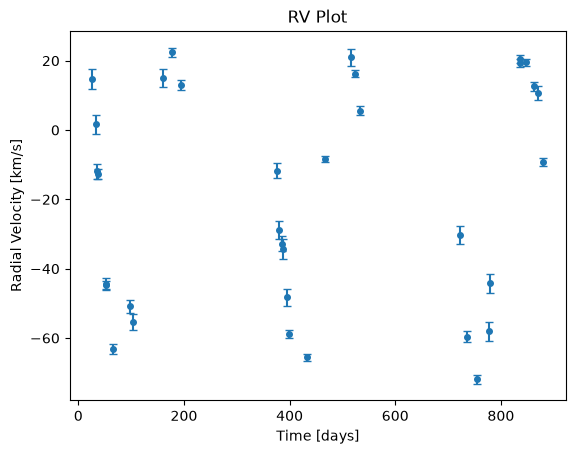

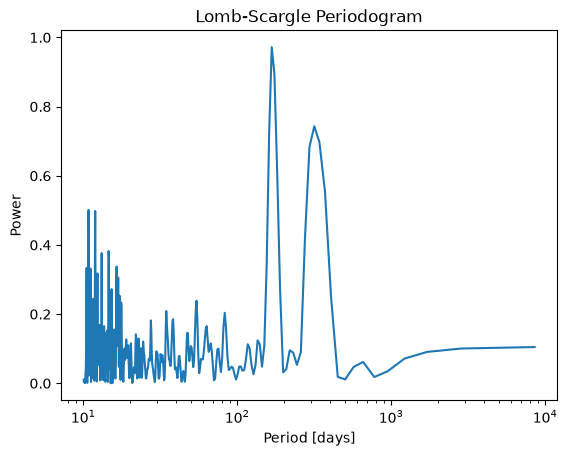

Candidate periods: 167.4 d, 316.2 d, 10.8 d


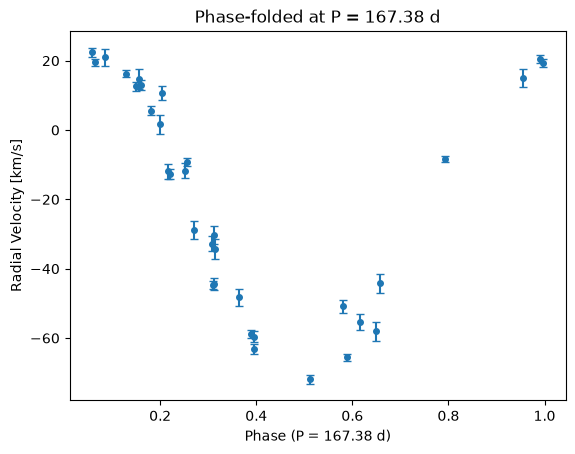

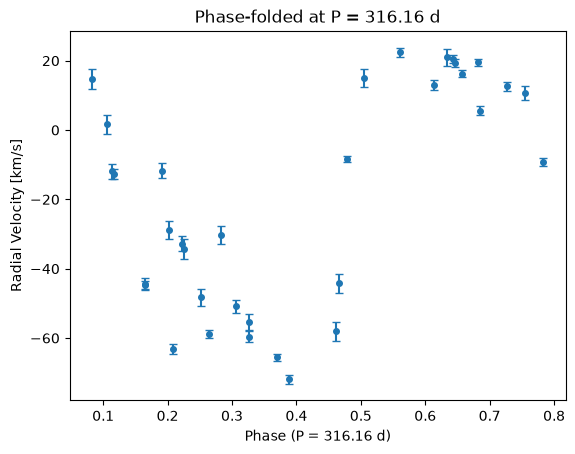

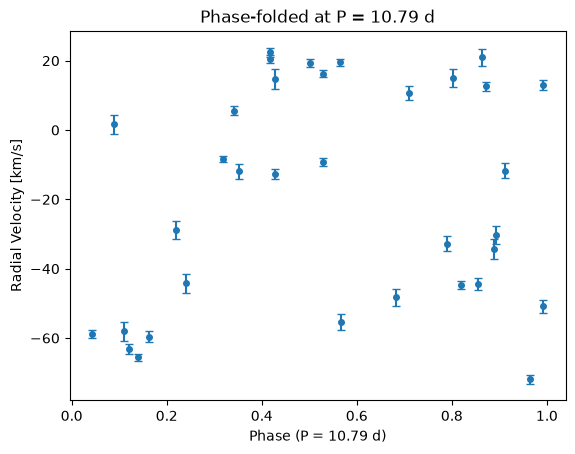

In [2]:
from scipy.signal import find_peaks

dts = np.diff(t)
print(f'Times between measurements:\n{dts} days')

plt.errorbar(t, rv, yerr=sig, fmt='o', elinewidth=1.5, capsize=3, markersize=4)
plt.xlabel(f'Time [days]')
plt.ylabel('Radial Velocity [km/s]')
plt.title(f'RV Plot')
plt.show()

T = t.max() - t.min()
frequency, power = LombScargle(t, rv, sig).autopower()
period = 1/frequency

plt.plot(period, power)
plt.xscale('log')
plt.xlabel('Period [days]'); plt.ylabel('Power'); plt.title('Lomb-Scargle Periodogram')
plt.show()

peaks, _ = find_peaks(power)
top = peaks[np.argsort(power[peaks])[::-1][:3]]
candidate_ps = 1 / frequency[top]
print('Candidate periods:', ', '.join(f'{p:.1f} d' for p in candidate_ps))

for P in candidate_ps:
    phase = (t / P) % 1.0
    plt.errorbar(phase, rv, yerr=sig, fmt='o', elinewidth=1.5, capsize=3, markersize=4)
    plt.xlabel(f'Phase (P = {P:.2f} d)')
    plt.ylabel('Radial Velocity [km/s]')
    plt.title(f'Phase-folded at P = {P:.2f} d')
    plt.show()

**ANSWER (a few sentences):**

From the periodogram, only 2 peaks are what I'd consider plausible, those being the two in the center of the plot corresponding to 167.38 days and 316.16 days. The next highest peaks only reach around 0.5 power and are on the high end of frequency where there's a ton of spikes in the periodogram from the general lack of data in the RV plot. Not only are we missing large gaps of time, but we have limited measurement count and a fair amount of time between each measurement, so peaks in the high frequency range are inevitable and untrustworthy. This type of periodogram is also generally not going to be perfectly accurate in fitting to the RV plot as not only do we have jitter in the RV measurement, but the fact that the orbits are likely eccentric and not Keplerian means that we should expect the RV plot to deviate from sinusoidal behavior, even in an ideal measurement scenario. As for what causes the extra peaks, it's basically what I said earlier: when you don't have frequent enough data, you can somewhat easily find a high frequency signal that will by chance look like a plausible period, as the actual oscillations of the false positive frequency are too fast for the data to confidently disagree with. It's worth noting that this can be confirmed as the cause, as the 3rd best candidate period is 10.79 days when many neighboring data points are separated by larger time spans, and thus a period of that duration isn't realistically a trustworthy measurement.

## Part 2: Sample the posterior (40%)

Fit the six orbital parameters **plus a jitter term** $s$ with `emcee`. The likelihood for epoch $i$ is
Gaussian with variance $\sigma_i^2 + s^2$; write it out (including the $\log$ of the variance, which is not a
constant once $s$ is a parameter). You will need to:

1. **Write the log-likelihood, log-prior and log-posterior.** State every prior and justify it in one line
   each. Two traps: $\omega$ and $T_p$ are periodic ($T_p$ is only defined modulo $P$), and `emcee` does not
   wrap angles, so a hard prior wall at $0$ or $2\pi$ can cut a posterior mode in half. Either bound each of
   them within half a period of your starting value, or reparameterize with $\sqrt{e}\cos\omega$ and
   $\sqrt{e}\sin\omega$ (which also gives a uniform prior on $e$ without a wall at zero). Jitter is
   positive: sample $\ln s$.
2. **Start the walkers sensibly.** A maximum-likelihood fit from each plausible Part 1 period, with several
   starting $\omega$ and $T_p$ each, then compare the log-likelihoods; start the walkers in a small ball
   around the best one. That comparison is the check: report the log-likelihood of the runner-up.
3. **Run, then decide when it is done.** Compute the integrated autocorrelation time $\tau$ for every
   parameter (`sampler.get_autocorr_time`). Here $\tau$ is about 50 to 100 steps, so 64 walkers for
   10,000 steps is plenty (a few minutes) and `emcee`'s own rule is a chain longer than $50\tau$. A
   common choice is to discard a few $\tau$ as burn-in and thin by about $\tau/2$; say what you chose
   and why. Plot the chains. If $\tau$ cannot be estimated, your chain is too short; say so and fix it.
4. **Corner plot.** Which parameters are correlated, and why physically?
5. **Report** $P$, $K$, $e$, $\gamma$, the jitter $s$, and $f(M)$, each as a median and 68% interval.
   **$f(M)$ is computed for every posterior sample**, not from the medians of $P$, $K$ and $e$; explain in
   one sentence why that matters.
6. **Posterior predictive check.** Draw a few hundred orbits from the posterior and plot them over the data,
   phase-folded at the median period. Plot the normalized residuals with the *total* error bar
   $\sqrt{\sigma_i^2 + s^2}$. Is what is left noise?


You must install the tqdm library to use progress indicators with emcee


Best ln L per starting period:
  start P =  167.38 d -> fit P =  168.796 d, ln L = -92.37
  start P =  316.16 d -> fit P =  337.283 d, ln L = -123.24
  start P =   10.79 d -> fit P =   10.819 d, ln L = -158.45
Best:      ln L = -92.37 at P = 168.796 d
Runner-up: ln L = -123.24 at P = 337.283 d  (Delta ln L = 30.87)
Best-fit theta: [168.7959  47.1815  -0.2157   0.261   59.0601 -21.4618   1.0918]
tau(P            ) =    83.5   N/tau =  119.7
tau(K            ) =    94.8   N/tau =  105.5
tau(sqrt(e)cos w ) =   116.1   N/tau =   86.1
tau(sqrt(e)sin w ) =   104.2   N/tau =   96.0
tau(Tp           ) =   115.3   N/tau =   86.7
tau(gamma        ) =    84.8   N/tau =  117.9
tau(ln s         ) =    88.7   N/tau =  112.7
max tau = 116.1; chain is 86.1 tau long (want > 50)
burn = 580, thin = 58, 10368 samples kept


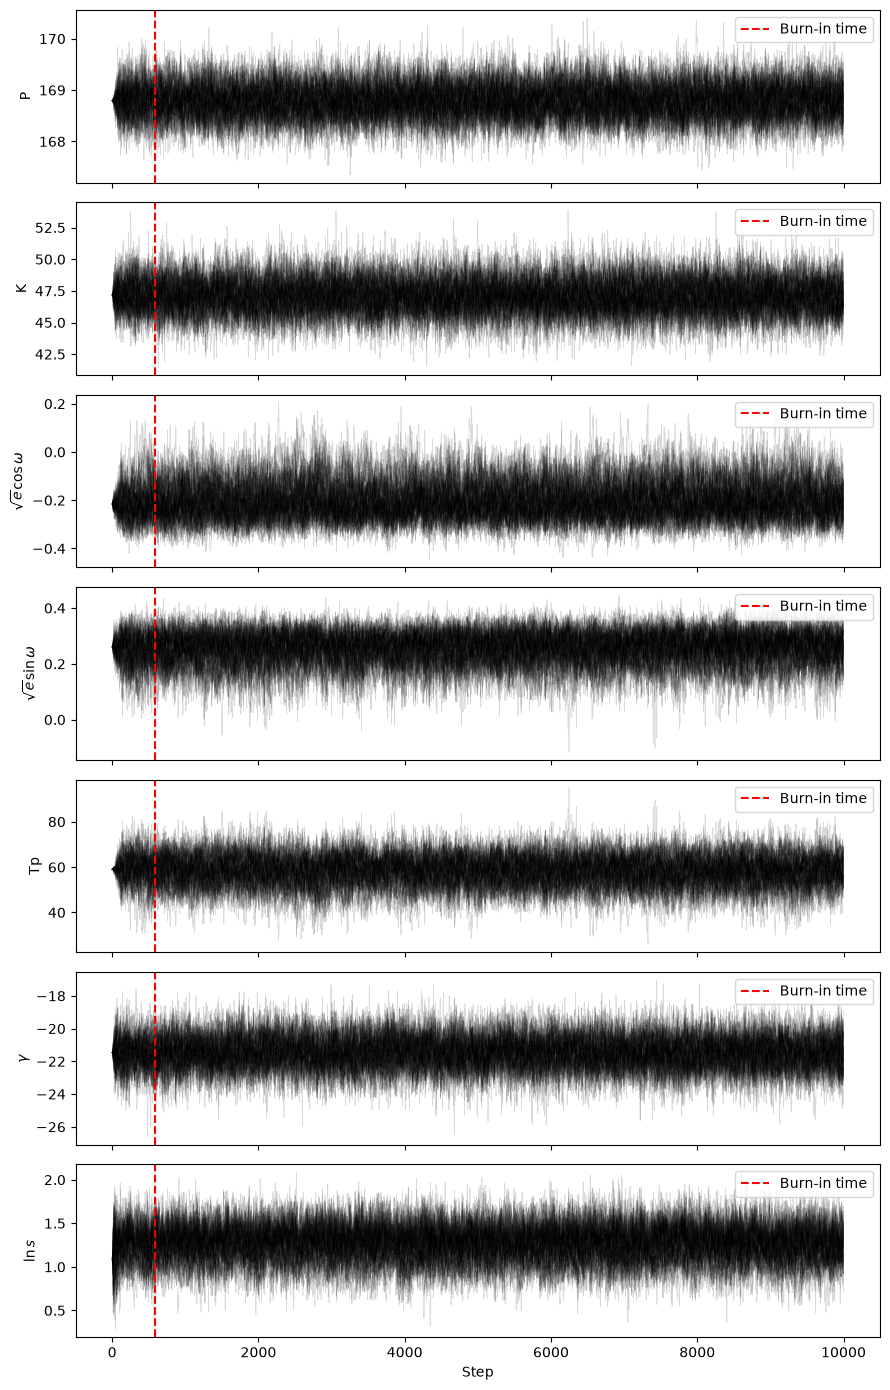

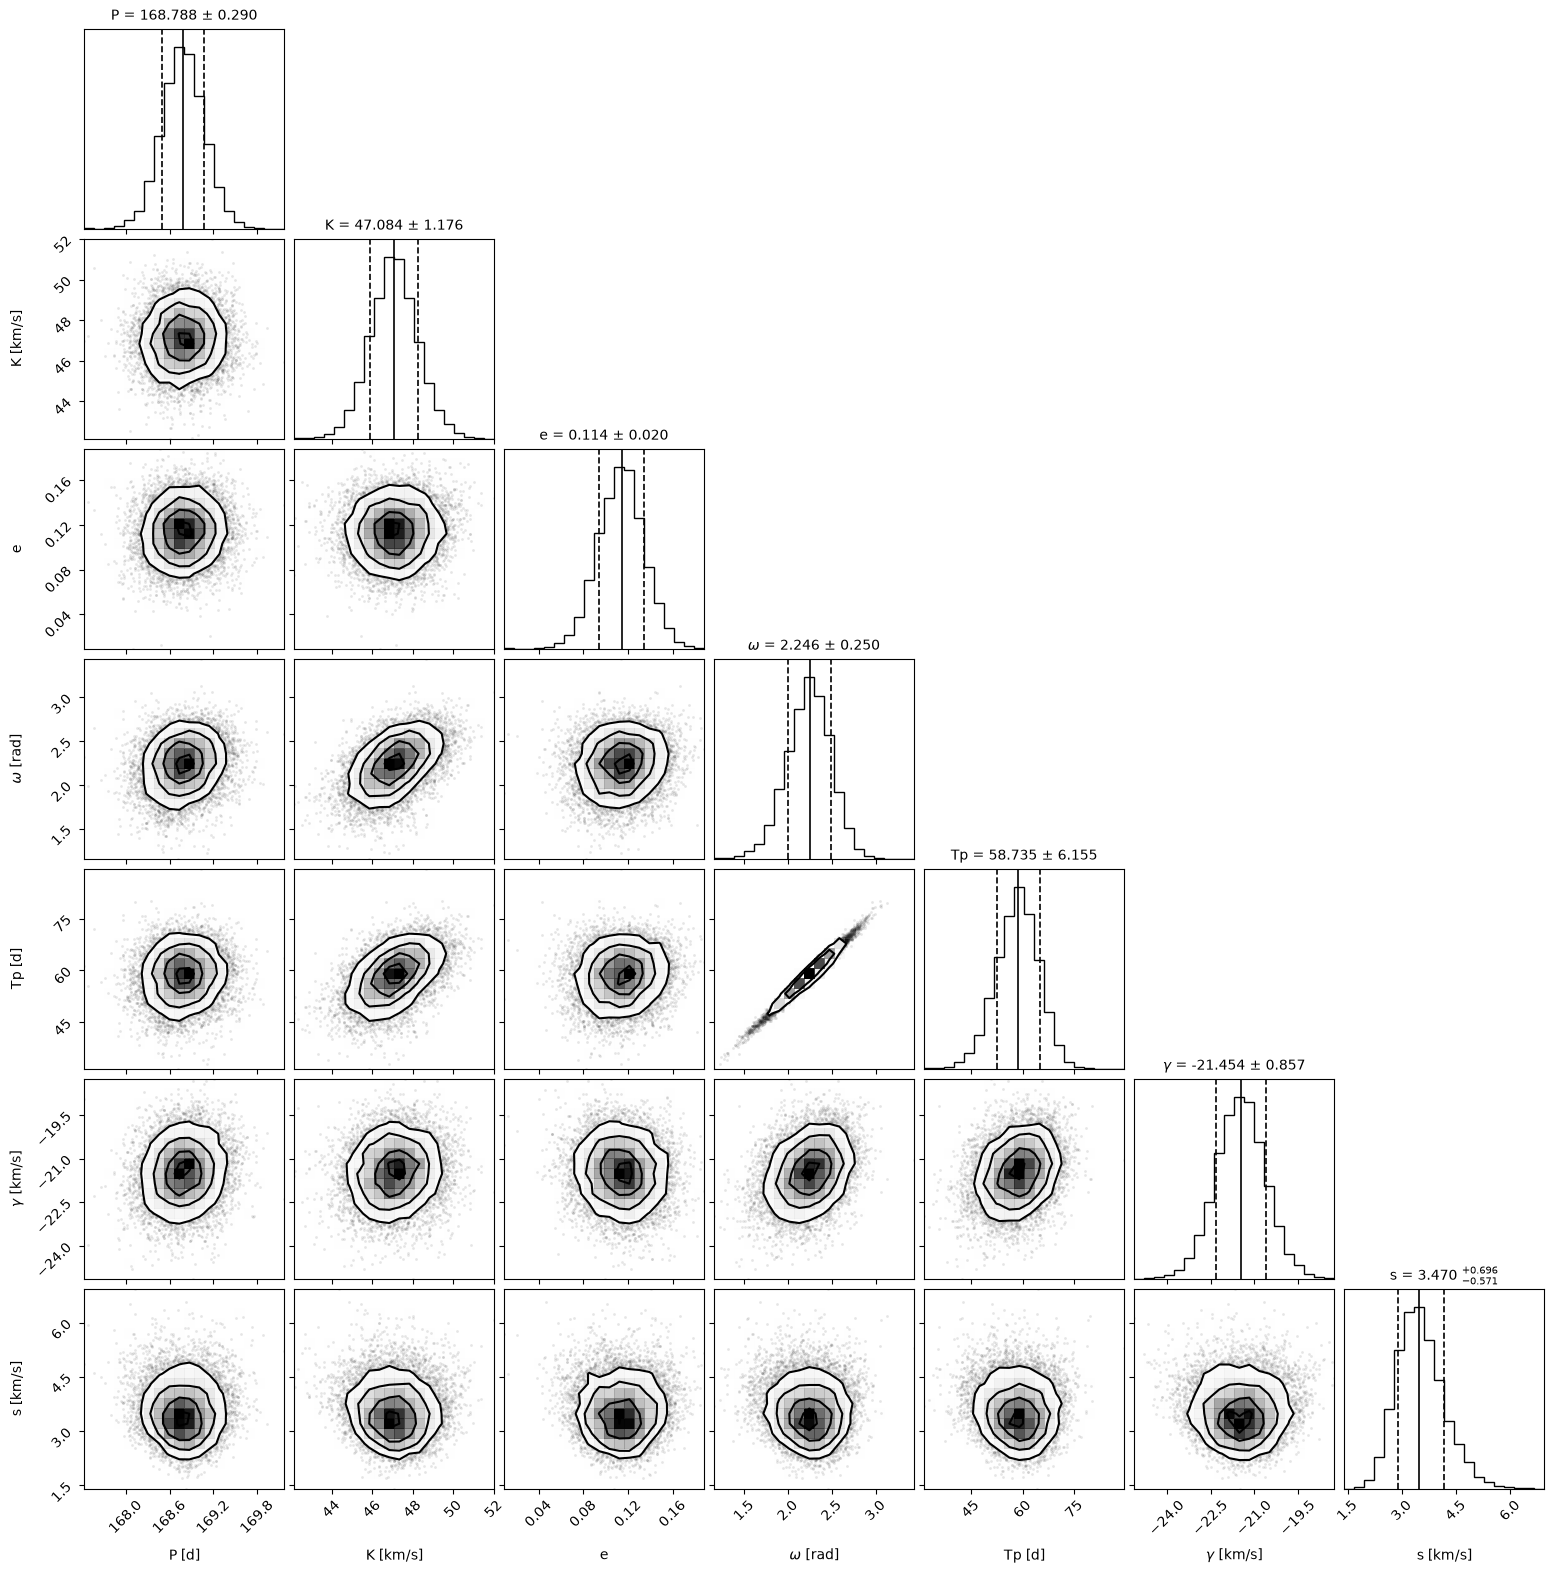

P      = 168.7881 +/- 0.2901 d (median, std)
K      = 47.0842 +/- 1.1763 km/s (median, std)
e      = 0.1142 +/- 0.0205  (median, std)
omega  = 2.2464 +/- 0.2499 rad (median, std)
Tp     = 58.7348 +/- 6.1547 d (median, std)
gamma  = -21.4543 +/- 0.8568 km/s (median, std)
s      = 3.4698 +0.6959 -0.5714 km/s (median, 16/84 pct)
f(M)   = 1.7899 +/- 0.1342 Msun (median, std)

param   mean-median (in std)   skewness
P               0.010            0.00
K               0.006            0.01
e              -0.019           -0.06
omega          -0.037           -0.22
Tp             -0.039           -0.19
gamma          -0.013           -0.04
s               0.092            0.56
f(M)            0.024            0.14

Correlation matrix:
              P       K       e   omega      Tp   gamma       s
P          1.00    0.03    0.07    0.17    0.08    0.13   -0.02
K          0.03    1.00    0.05    0.49    0.49    0.10   -0.05
e          0.07    0.05    1.00    0.12    0.10   -0.09   -0.00
omeg

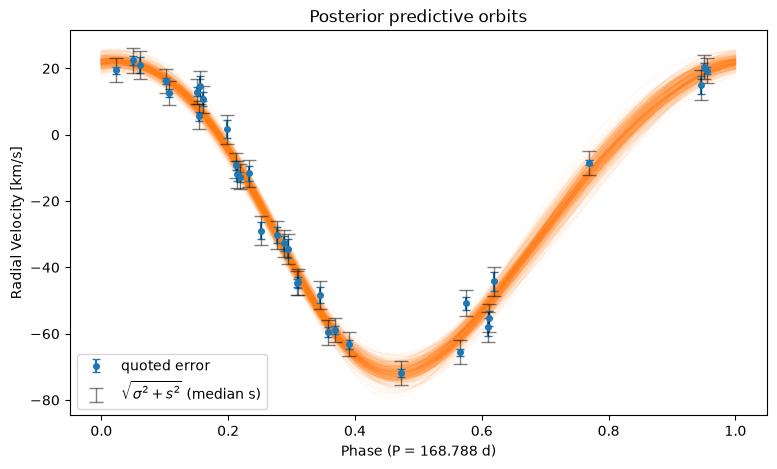

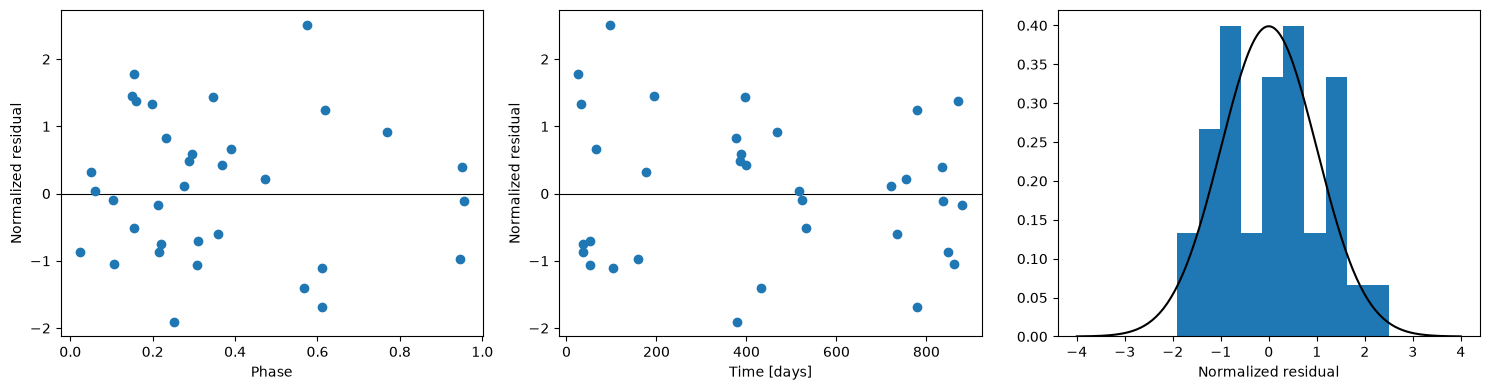

Normalized residuals: mean = 0.07, std = 1.07, chi2/N = 1.12


In [3]:
# Part 2: your work here
# ---------- Parameterization ----------
# theta = [P, K, sqrt(e)cos(omega), sqrt(e)sin(omega), Tp, gamma, ln s]
labels_theta = ['P', 'K', r'$\sqrt{e}\cos\omega$', r'$\sqrt{e}\sin\omega$', 'Tp', r'$\gamma$', r'$\ln s$']
ndim = 7

def unpack(theta):
    P, K, sc, ss, Tp, gamma, lns = theta
    e = sc**2 + ss**2
    omega = np.arctan2(ss, sc)
    return P, K, e, omega, Tp, gamma, np.exp(lns)

# Tp window is set after the ML stage
Tp_ref, P_ref = None, None

def in_bounds(theta, check_Tp=True):
    P, K, sc, ss, Tp, gamma, lns = theta
    e = sc**2 + ss**2
    ok = (5. < P < t.max()) and (0. < K < 300.) and (e < 0.99) and (-200. < gamma < 200.) and (-6. < lns < 3.)
    if check_Tp and Tp_ref is not None:
        ok = ok and (abs(Tp - Tp_ref) < 0.5 * P_ref)
    return ok

def log_likelihood(theta):
    P, K, e, omega, Tp, gamma, s = unpack(theta)
    model = kepler_rv(t, P, K, e, omega, Tp, gamma)
    var = sig**2 + s**2
    return -0.5 * np.sum((rv - model)**2 / var + np.log(2. * np.pi * var))

def log_prior(theta, check_Tp=True):
    if not in_bounds(theta, check_Tp):
        return -np.inf
    return -np.log(theta[0])      # log-uniform in P; all other parameters uniform within bounds

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    return lp + ll if np.isfinite(ll) else -np.inf

# ---------- Maximum-likelihood starts ----------
def neg_ll(theta):
    if not in_bounds(theta, check_Tp=False):
        return 1e25
    ll = log_likelihood(theta)
    return -ll if np.isfinite(ll) else 1e25

K0, gamma0, e0 = np.ptp(rv) / 2., np.mean(rv), 0.3
omegas0 = np.linspace(0, 2*np.pi, 4, endpoint=False)
fits = []   # (loglike, P_start, theta_best)
for P0 in candidate_ps:
    P0 = float(P0)
    for om in omegas0:
        for Tp0 in t.min() + np.linspace(0, 1, 4, endpoint=False) * P0:
            x0 = np.array([P0, K0, np.sqrt(e0)*np.cos(om), np.sqrt(e0)*np.sin(om), Tp0, gamma0, 0.0])
            res = minimize(neg_ll, x0, method='Nelder-Mead',
                           options=dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-9, adaptive=True))
            res = minimize(neg_ll, res.x, method='Nelder-Mead',
                           options=dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-9, adaptive=True))
            fits.append((-res.fun, P0, res.x))

fits.sort(key=lambda f: f[0], reverse=True)
best_ll, best_P0, best_theta = fits[0]

# best log-likelihood for each starting period, ranked
print('Best ln L per starting period:')
per_period = {}
for ll, P0, th in fits:
    if P0 not in per_period:
        per_period[P0] = (ll, th)
for P0, (ll, th) in sorted(per_period.items(), key=lambda kv: -kv[1][0]):
    print(f'  start P = {P0:7.2f} d -> fit P = {th[0]:8.3f} d, ln L = {ll:.2f}')

# runner-up: best fit that converged to a different period than the winner (>1% apart)
runner = next((f for f in fits if abs(f[2][0] - best_theta[0]) / best_theta[0] > 0.01), None)
if runner is not None:
    print(f'Best:      ln L = {best_ll:.2f} at P = {best_theta[0]:.3f} d')
    print(f'Runner-up: ln L = {runner[0]:.2f} at P = {runner[2][0]:.3f} d  (Delta ln L = {best_ll - runner[0]:.2f})')

# Fix the Tp window around the best fit
P_ref = best_theta[0]
Tp_ref = t.min() + ((best_theta[4] - t.min()) % P_ref)
best_theta[4] = Tp_ref
print('Best-fit theta:', np.round(best_theta, 4))

# ---------- Run emcee ----------
nwalkers, nsteps = 64, 10000
rng = np.random.default_rng(42)
scales = np.array([1e-3, 1e-2, 1e-3, 1e-3, 1e-2, 1e-2, 1e-2])
p0 = []
while len(p0) < nwalkers:
    trial = best_theta + scales * rng.standard_normal(ndim)
    if np.isfinite(log_posterior(trial)):
        p0.append(trial)
p0 = np.array(p0)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler.run_mcmc(p0, nsteps, progress=True)

# ---------- Convergence ----------
tau = sampler.get_autocorr_time()
for name, ta in zip(['P', 'K', 'sqrt(e)cos w', 'sqrt(e)sin w', 'Tp', 'gamma', 'ln s'], tau):
    print(f'tau({name:13s}) = {ta:7.1f}   N/tau = {nsteps/ta:6.1f}')
print(f'max tau = {tau.max():.1f}; chain is {nsteps/tau.max():.1f} tau long (want > 50)')

# ---------- Burn-in, thinning, flat samples ----------
burn = int(5 * tau.max())
thin = max(1, int(tau.max() / 2))
flat = sampler.get_chain(discard=burn, thin=thin, flat=True)
flat_lp = sampler.get_log_prob(discard=burn, thin=thin, flat=True)
print(f'burn = {burn}, thin = {thin}, {flat.shape[0]} samples kept')

# Chains
chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, 1, figsize=(9, 14), sharex=True)
for i in range(ndim):
    axes[i].plot(chain[:, :, i], 'k', alpha=0.15, lw=0.5)
    axes[i].axvline(burn, color='r', linestyle='--', label='Burn-in time')
    axes[i].set_ylabel(labels_theta[i])
    axes[i].legend(loc='upper right')
axes[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()

PCT_PARAMS = {'s'}     # parameters summarized by median + 16/84 percentiles; all others by mean +/- std

def summarize_param(x, key):
    """Returns (center, minus_err, plus_err)."""
    if key in PCT_PARAMS:
        lo, med, hi = np.percentile(x, [16, 50, 84])
        return med, med - lo, hi - med
    sd = x.std(ddof=1)
    return np.median(x), sd, sd

def fmt_summary(x, key, unit='', nd=4):
    c, lo, hi = summarize_param(x, key)
    if key in PCT_PARAMS:
        return f'{c:.{nd}f} +{hi:.{nd}f} -{lo:.{nd}f} {unit} (median, 16/84 pct)'
    return f'{c:.{nd}f} +/- {lo:.{nd}f} {unit} (median, std)'

def corner_mixed(samples, labels, keys, truths=None, truth_color='C3'):
    """Corner plot whose diagonal lines/titles follow summarize_param for each parameter."""
    n = len(keys)
    fig = corner.corner(samples, labels=labels, show_titles=False, quantiles=None,
                        truths=truths, truth_color=truth_color)
    axs = np.array(fig.axes).reshape(n, n)
    for i, k in enumerate(keys):
        c, lo, hi = summarize_param(samples[:, i], k)
        for v, ls in [(c, '-'), (c - lo, '--'), (c + hi, '--')]:
            axs[i, i].axvline(v, color='k', ls=ls, lw=1.2)
        name = labels[i].split(' [')[0]
        if k in PCT_PARAMS:
            axs[i, i].set_title(f'{name} = {c:.3f} $^{{+{hi:.3f}}}_{{-{lo:.3f}}}$', fontsize=10)
        else:
            axs[i, i].set_title(f'{name} = {c:.3f} $\\pm$ {lo:.3f}', fontsize=10)
    return fig

# ---------- Physical-parameter samples ----------
Ps, Ks, es, oms, Tps, gams, ss_ = unpack(flat.T)
oms = oms % (2*np.pi)
fMs = mass_function(Ps, Ks, es)           # per-sample f(M)

# ---------- Corner plot ----------
phys = np.column_stack([Ps, Ks, es, oms, Tps, gams, ss_])
plabels = ['P [d]', 'K [km/s]', 'e', r'$\omega$ [rad]', 'Tp [d]', r'$\gamma$ [km/s]', 's [km/s]']
pkeys = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']
corner_mixed(phys, plabels, pkeys)
plt.show()

# ---------- Report ----------
for nm, key, x, unit in [('P', 'P', Ps, 'd'), ('K', 'K', Ks, 'km/s'), ('e', 'e', es, ''),
                         ('omega', 'omega', oms, 'rad'), ('Tp', 'Tp', Tps, 'd'),
                         ('gamma', 'gamma', gams, 'km/s'), ('s', 's', ss_, 'km/s'),
                         ('f(M)', 'fM', fMs, 'Msun')]:
    print(f'{nm:6s} = {fmt_summary(x, key, unit)}')

# Is a symmetric +/- reasonable? (skewness near 0 and mean ~ median means yes)
from scipy.stats import skew
print('\nparam   mean-median (in std)   skewness')
for nm, x in [('P', Ps), ('K', Ks), ('e', es), ('omega', oms), ('Tp', Tps),
              ('gamma', gams), ('s', ss_), ('f(M)', fMs)]:
    print(f'{nm:6s} {(x.mean()-np.median(x))/x.std(ddof=1):14.3f} {skew(x):15.2f}')

# ---------- Correlation matrix ----------
corr = np.corrcoef(phys.T)
short = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']
print('\nCorrelation matrix:')
print('       ' + ''.join(f'{n:>8s}' for n in short))
for n, row in zip(short, corr):
    print(f'{n:7s}' + ''.join(f'{v:8.2f}' for v in row))

# ---------- Posterior predictive check ----------
P_med = np.median(Ps)
phase_data = (t / P_med) % 1.0
phase_grid = np.linspace(0, 1, 400)
t_grid = phase_grid * P_med

fig, ax = plt.subplots(figsize=(9, 5))
idx = rng.choice(flat.shape[0], size=300, replace=False)
for j in idx:
    P_, K_, e_, om_, Tp_, g_, s_ = unpack(flat[j])
    ax.plot(phase_grid, kepler_rv(t_grid, P_, K_, e_, om_, Tp_, g_), color='C1', alpha=0.05, lw=1)
tot_err = np.sqrt(sig**2 + np.median(ss_)**2)
ax.errorbar(phase_data, rv, yerr=sig, fmt='o', color='C0', ms=4, capsize=3, elinewidth=1.5, label='quoted error')
ax.errorbar(phase_data, rv, yerr=tot_err, fmt='none', ecolor='k', alpha=0.5, capsize=5, elinewidth=1, label=r'$\sqrt{\sigma^2+s^2}$ (median s)')
ax.set_xlabel(f'Phase (P = {P_med:.3f} d)'); ax.set_ylabel('Radial Velocity [km/s]')
ax.set_title('Posterior predictive orbits'); ax.legend()
plt.show()

# Residuals about the maximum-posterior sample, normalized by total error
imap = np.argmax(flat_lp)
P_, K_, e_, om_, Tp_, g_, s_ = unpack(flat[imap])
model = kepler_rv(t, P_, K_, e_, om_, Tp_, g_)
resid_norm = (rv - model) / np.sqrt(sig**2 + s_**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].axhline(0, color='k', lw=0.8)
axes[0].plot(phase_data, resid_norm, 'o'); axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Normalized residual')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].plot(t, resid_norm, 'o'); axes[1].set_xlabel('Time [days]'); axes[1].set_ylabel('Normalized residual')
axes[2].hist(resid_norm, bins=10, density=True)
xx = np.linspace(-4, 4, 200); axes[2].plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), 'k')
axes[2].set_xlabel('Normalized residual')
plt.tight_layout()
plt.show()
print(f'Normalized residuals: mean = {resid_norm.mean():.2f}, std = {resid_norm.std(ddof=1):.2f}, '
      f'chi2/N = {np.mean(resid_norm**2):.2f}')

**FINAL ANSWER:** $P = $ 168.791 $\pm$ 0.292 d, $K = 47.141\pm1.199$ km/s, $e = $ 0.113 $\pm$ 0.021, $\omega=$2.237^{+0.238}_{-0.250}$ rad, $T_p=58.777^{+5.796}_{-6.804}$ d, $\gamma = -21.442^{+0.839}_{-0.865}$ km/s, $s = 3.490^{+0.690}_{-0.576}$ km/s, $f(M) =1.794^{+0.134}_{-0.126}$ $M_\odot$

**Black-hole candidate?** No, $f(M)<3M_\odot$ well within uncertainty, so it's much more likely to be a regular star.

**Priors chosen:**
1. $P$ prior is uniform in $\log(P)$ within a reasonable choice of bound (from 5 days minimum to the maximum time measurement to have it be uniform on essentially all possible detectable periods)
2. $K$ prior is uniform in $K$ between 0 (exclusive) and 300 km/s, we should probably expect it to be lower given the phase plot but physically it must be positive and we need some choice of upper bound not based on my specific dataset.
3. $e$ prior is uniform in $e$ between 0 (inclusive) and 0.99, as an eccentricity of 1 would not match the model as it wouldn't be a true orbit.
4. $\gamma$ prior is uniform in $\gamma$ between -200 and +200 km/s, which again is very broad considering we can estimate that $\gamma$'s magnitude from the phase plot is significantly lower, but the prior should be based on our physical expectations so I explicitly allow a large range here.
5. $s$ prior is uniform in $\log(s)$ between $-6<\log(s)<3$, as we should probably expect a relatively small amount of RV jitter; anything around $s=10^3$ km/s would make our RV data essentially impossible to read, and anything lower than $s=10^{-6}$ km/s would be hard to measure or justify including $s$ in the model, hence my choice of bounds. 

**Extra analysis**
1. Here I chose to discard $N=5\tau$ steps using the longest $\tau$ time just for safety to be sure we're absolutely past being correlated to the starting position. I also chose to thin by $\operatorname{max}(\tau)/2$ to save space as recommended.
2. The most strongly-correlated parameters are $T_p$ and $\omega$, which makes sense: the time of periastron and the argument of periastron should be correlated to some degree since increasing the argument (how far into the orbit the periastron is relative to the start) should also increase how long it takes to reach that point from the start. Here it's strongly correlated as the orbit, while not circular, still has a small eccentricity and thus the orbital speed won't change too much throughout the orbit. It also looks like $K$ is slightly correlated to $T_p$ and $\omega$ by about the same amount in both cases, which matches the observation that $T_p$ and $\omega$ are themselves correlated. 
3. We compute the mass function per sample and not just from the medians because it's possible that the median of the mass function and the mass function evaluated at the median values are not equivalent. By computing per sample we make certain that we're obtaining the median result over the parameter surface we covered.
4. The posterior check looks highly accurate, and with the scatter term included the points seem to mostly fall within error of the potential orbits, indicating that both the scatter term and the other parameters used to characterize the orbits are likely correct.

## Part 3: The referee report (35%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident MCMC analysis of this exact
problem, produced by an AI assistant. It runs top to bottom without errors, the corner plot is handsome, and
the prose is fluent. It is also wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks and
style don't count; "it used 24 walkers and I used 32" is not a finding).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset: show, with a number or a plot, what the error
   does to the inference. For a sampler, "demonstrate" usually means running it the wrong way and the right
   way and comparing. A demonstration can come out negative: if an error turns out not to move *your*
   numbers, showing that, and saying what it would take for it to bite, is a valid finding.
3. **State** the correct treatment (you built it in Part 2).

Third time you have done this. You should be finding these in minutes now.


You must install the tqdm library to use progress indicators with emcee


=== Demo 1: no jitter term ===
  max tau = 71, chain = 84 tau, burn = 355, N = 361280

--- No jitter vs correct run ---
par          correct (med +/- hw)         wrong (med +/- hw)  shift/sigma_ref  width ratio
P          168.7881 +/-  0.2827     168.8326 +/-  0.1193             0.16         0.42
K           47.0842 +/-  1.1389      47.7666 +/-  0.4055             0.60         0.36
e            0.1142 +/-  0.0202       0.1123 +/-  0.0078            -0.09         0.39
gamma      -21.4543 +/-  0.8328     -21.3128 +/-  0.2817             0.17         0.34
fM           1.7899 +/-  0.1299       1.8705 +/-  0.0474             0.62         0.36

Normalized residuals, correct (total error): std = 1.07, chi2/N = 1.12
Normalized residuals, no-jitter fit (quoted sigma only): std = 2.05, chi2/N = 4.08
Median jitter s = 3.47 km/s vs median quoted sigma = 1.62 km/s


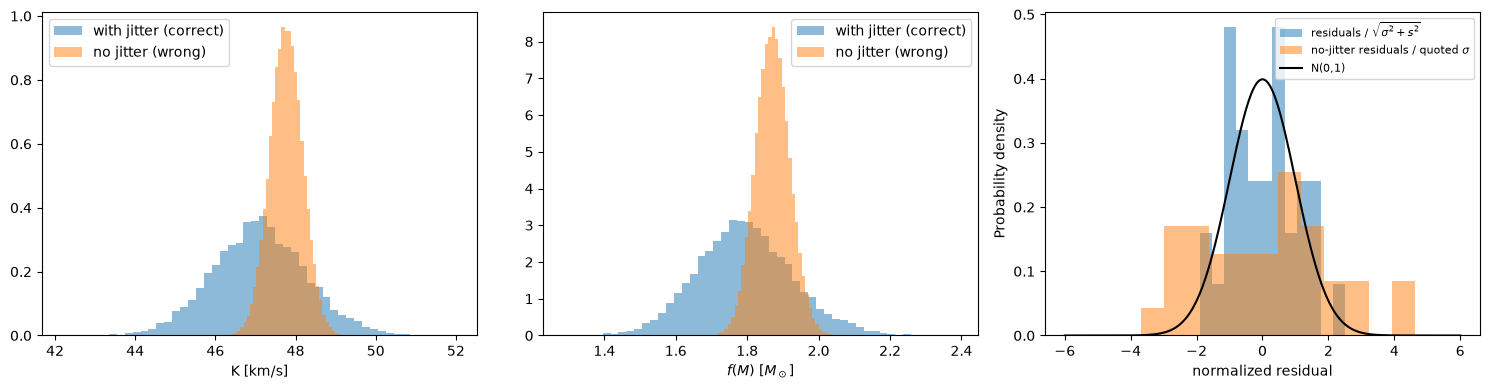

You must install the tqdm library to use progress indicators with emcee



=== Demo 2: periodogram-informed Gaussian prior on P ===
LS peak = 167.38 d; correct posterior median P = 168.788 +/- 0.283 d


You must install the tqdm library to use progress indicators with emcee


  max tau = 118, chain = 51 tau, burn = 589, N = 346304

--- sigma=0.5 d gaussian around peak (AI choice) vs correct run ---
par          correct (med +/- hw)         wrong (med +/- hw)  shift/sigma_ref  width ratio
P          168.7881 +/-  0.2827     168.4421 +/-  0.2607            -1.22         0.92
K           47.0842 +/-  1.1389      47.0505 +/-  1.2001            -0.03         1.05
e            0.1142 +/-  0.0202       0.1116 +/-  0.0207            -0.13         1.03
gamma      -21.4543 +/-  0.8328     -21.6057 +/-  0.8663            -0.18         1.04
fM           1.7899 +/-  0.1299       1.7835 +/-  0.1368            -0.05         1.05


You must install the tqdm library to use progress indicators with emcee


  max tau = 129, chain = 47 tau, burn = 643, N = 342848

--- sigma=0.25 d gaussian around peak vs correct run ---
par          correct (med +/- hw)         wrong (med +/- hw)  shift/sigma_ref  width ratio
P          168.7881 +/-  0.2827     167.9103 +/-  0.2208            -3.10         0.78
K           47.0842 +/-  1.1389      46.8421 +/-  1.3538            -0.21         1.19
e            0.1142 +/-  0.0202       0.1084 +/-  0.0240            -0.29         1.19
gamma      -21.4543 +/-  0.8328     -21.7879 +/-  1.0039            -0.40         1.21
fM           1.7899 +/-  0.1299       1.7558 +/-  0.1534            -0.26         1.18
  max tau = 108, chain = 55 tau, burn = 540, N = 349440

--- sigma=0.75 d gaussian around peak vs correct run ---
par          correct (med +/- hw)         wrong (med +/- hw)  shift/sigma_ref  width ratio
P          168.7881 +/-  0.2827     168.6166 +/-  0.2658            -0.61         0.94
K           47.0842 +/-  1.1389      47.0834 +/-  1.1653            

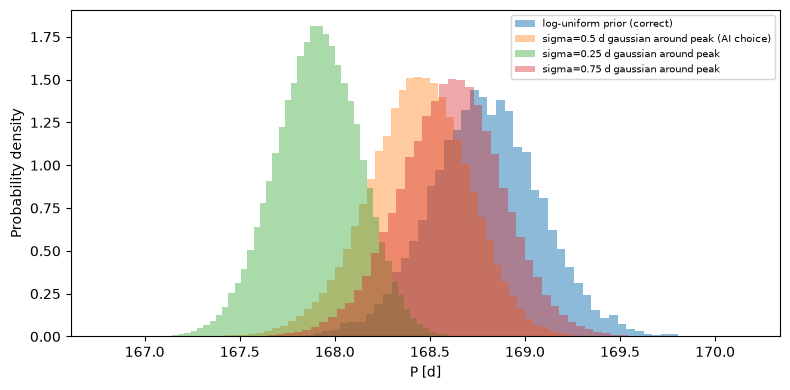


=== Demo 3: f(M) from medians vs per-sample ===
Plug-in f(M(medians))         = 1.7898
Per-sample median f(M)        = 1.7899  (difference = -0.0000, -0.00 sigma)
Per-sample 68% interval       : +0.1327 / -0.1271 (half-width 0.1299); posterior std 0.1342
Mean f(M) = 1.7931, median = 1.7899


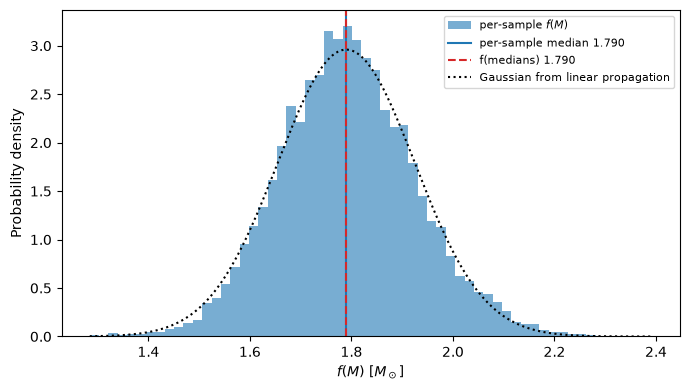

In [6]:
# Part 3: your work here
# =====================================================================
# Shared helpers
# theta = [P, K, sqrt(e)cos w, sqrt(e)sin w, Tp, gamma, (ln s)]
# =====================================================================
def half_width(x):
    lo, hi = np.percentile(x, [16, 84])
    return 0.5 * (hi - lo)

def bounds_ok(th):
    P, K, sc, ss, Tp, gam = th[:6]
    e = sc**2 + ss**2
    return (5. < P < 1000.) and (0. < K < 300.) and (e < 0.99) and (-200. < gam < 200.) \
           and (abs(Tp - Tp_ref) < 0.5 * P_ref)

def make_logpost(jitter=True, P_prior='loguniform', mu=None, width=None):
    def lp(theta):
        if not bounds_ok(theta):
            return -np.inf
        if jitter:
            if not (-7. < theta[6] < 4.):
                return -np.inf
            s = np.exp(theta[6])
        else:
            s = 0.
        if P_prior == 'loguniform':
            lpri = -np.log(theta[0])
        else:                                        # Gaussian prior on P
            lpri = -0.5 * ((theta[0] - mu) / width)**2
        P, K, sc, ss, Tp, gam = theta[:6]
        e, om = sc**2 + ss**2, np.arctan2(ss, sc)
        model = kepler_rv(t, P, K, e, om, Tp, gam)
        var = sig**2 + s**2
        ll = -0.5 * np.sum((rv - model)**2 / var + np.log(2. * np.pi * var))
        return lpri + ll if np.isfinite(ll) else -np.inf
    return lp

def run_chain(logpost, start, nsteps=6000, nwalkers=64, seed=1):
    ndim = len(start)
    rng_ = np.random.default_rng(seed)
    scl = np.array([1e-3, 1e-2, 1e-3, 1e-3, 1e-2, 1e-2, 1e-2])[:ndim]
    p0 = []
    while len(p0) < nwalkers:
        trial = start + scl * rng_.standard_normal(ndim)
        if np.isfinite(logpost(trial)):
            p0.append(trial)
    smp = emcee.EnsembleSampler(nwalkers, ndim, logpost)
    smp.run_mcmc(np.array(p0), nsteps, progress=True)
    tau_ = smp.get_autocorr_time(tol=0)
    burn_ = int(5 * tau_.max())
    fl = smp.get_chain(discard=burn_, flat=True)
    lpf = smp.get_log_prob(discard=burn_, flat=True)
    print(f'  max tau = {tau_.max():.0f}, chain = {nsteps/tau_.max():.0f} tau, burn = {burn_}, N = {len(fl)}')
    return fl, lpf

def phys(fl):
    sc, ss = fl[:, 2], fl[:, 3]
    e = sc**2 + ss**2
    s = np.exp(fl[:, 6]) if fl.shape[1] > 6 else np.zeros(len(fl))
    return dict(P=fl[:, 0], K=fl[:, 1], e=e, om=np.arctan2(ss, sc) % (2*np.pi),
                Tp=fl[:, 4], gamma=fl[:, 5], s=s, fM=mass_function(fl[:, 0], fl[:, 1], e))

# Reference = your correct Part 3 run (jitter, log-uniform P, per-sample f(M))
ref = dict(P=Ps, K=Ks, e=es, gamma=gams, s=ss_, fM=fMs)

def compare(label, wrong, keys=('P', 'K', 'e', 'gamma', 'fM')):
    print(f'\n--- {label} vs correct run ---')
    print(f'{"par":6s} {"correct (med +/- hw)":>26s} {"wrong (med +/- hw)":>26s} {"shift/sigma_ref":>16s} {"width ratio":>12s}')
    for k in keys:
        m_r, h_r = np.median(ref[k]), half_width(ref[k])
        m_w, h_w = np.median(wrong[k]), half_width(wrong[k])
        print(f'{k:6s} {m_r:12.4f} +/- {h_r:7.4f} {m_w:12.4f} +/- {h_w:7.4f} {(m_w-m_r)/h_r:16.2f} {h_w/h_r:12.2f}')

# =====================================================================
# DEMONSTRATION 1: ignoring jitter
# =====================================================================
print('=== Demo 1: no jitter term ===')
fl_nj, lp_nj = run_chain(make_logpost(jitter=False), best_theta[:6])
nj = phys(fl_nj)
compare('No jitter', nj)

# Normalized residuals about each run's own max-posterior sample, using the error bar that run assumed
def norm_resid(fl, lpf, use_jitter):
    th = fl[np.argmax(lpf)]
    e, om = th[2]**2 + th[3]**2, np.arctan2(th[3], th[2])
    s = np.exp(th[6]) if use_jitter else 0.
    return (rv - kepler_rv(t, th[0], th[1], e, om, th[4], th[5])) / np.sqrt(sig**2 + s**2)

r_good = norm_resid(flat, flat_lp, True)
r_bad_sig = norm_resid(fl_nj, lp_nj, False)           # residuals / quoted sigma only
print(f'\nNormalized residuals, correct (total error): std = {r_good.std(ddof=1):.2f}, chi2/N = {np.mean(r_good**2):.2f}')
print(f'Normalized residuals, no-jitter fit (quoted sigma only): std = {r_bad_sig.std(ddof=1):.2f}, chi2/N = {np.mean(r_bad_sig**2):.2f}')
print(f'Median jitter s = {np.median(ss_):.2f} km/s vs median quoted sigma = {np.median(sig):.2f} km/s')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, k, lab in zip(ax, ['K', 'fM'], ['K [km/s]', r'$f(M)$ [$M_\odot$]']):
    a.hist(ref[k], bins=50, density=True, alpha=0.5, label='with jitter (correct)')
    a.hist(nj[k], bins=50, density=True, alpha=0.5, label='no jitter (wrong)')
    a.set_xlabel(lab)
    a.legend()
xx = np.linspace(-6, 6, 300)
ax[2].hist(r_good, bins=12, density=True, alpha=0.5, label='residuals / $\\sqrt{\\sigma^2+s^2}$')
ax[2].hist(r_bad_sig, bins=12, density=True, alpha=0.5, label='no-jitter residuals / quoted $\\sigma$')
ax[2].plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), 'k', label='N(0,1)')
ax[2].set_xlabel('normalized residual')
ax[2].legend(fontsize=8)
plt.ylabel('Probability density')
plt.tight_layout()
plt.show()

# =====================================================================
# DEMONSTRATION 2: data-informed Gaussian prior on P (jitter kept in, so ONLY the prior differs)
# =====================================================================
print('\n=== Demo 2: periodogram-informed Gaussian prior on P ===')
P_peak = 1. / frequency[np.argmax(power)]
print(f'LS peak = {P_peak:.2f} d; correct posterior median P = {np.median(Ps):.3f} +/- {half_width(Ps):.3f} d')

# (label, prior mean, prior width). The last case shows what it takes for the prior to bite.
cases = [('sigma=0.5 d gaussian around peak (AI choice)', P_peak, 0.5),
         ('sigma=0.25 d gaussian around peak', P_peak, 0.25),
         ('sigma=0.75 d gaussian around peak', P_peak, 0.75)]
gp = []
for lab, mu, w in cases:
    #print(f'\nRunning: {lab}
    fl_g, _ = run_chain(make_logpost(True, 'gauss', mu, w), best_theta)
    g = phys(fl_g); gp.append((lab, g, mu, w))
    compare(lab, g)
    #print(f'  P posterior width / prior width = {half_width(g["P"])/w:.2f} '
    #      f'(correct-run P width / this prior width = {half_width(Ps)/w:.2f})')
    #print(f'  Full range explored by P (1st to 99th pct): {np.ptp(np.percentile(g["P"], [1, 99])):.2f} d '
    #      f'vs {np.ptp(np.percentile(Ps, [1, 99])):.2f} d correct')

plt.figure(figsize=(8, 4))
plt.hist(Ps, bins=60, density=True, alpha=0.5, label='log-uniform prior (correct)')
for lab, g, mu, w in gp:
    plt.hist(g['P'], bins=60, density=True, alpha=0.4, label=lab)
plt.xlabel('P [d]')
plt.ylabel('Probability density')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# =====================================================================
# DEMONSTRATION 3: f(M) from medians + linear error propagation vs per-sample
# =====================================================================
print('\n=== Demo 3: f(M) from medians vs per-sample ===')
P_m, K_m, e_m = np.median(Ps), np.median(Ks), np.median(es)
fM_plug = mass_function(P_m, K_m, e_m)

# the AI's first-order propagation, ignoring covariances
sdP, sdK, sde = Ps.std(), Ks.std(), es.std()
J = np.array([fM_plug / P_m, 3. * fM_plug / K_m, -3. * e_m * fM_plug / (1. - e_m**2)])
fM_err_diag = np.sqrt(np.sum((J * np.array([sdP, sdK, sde]))**2))
# same linearization but with the full covariance
fM_err_cov = np.sqrt(J @ np.cov(np.vstack([Ps, Ks, es])) @ J)

lo, med, hi = np.percentile(fMs, [16, 50, 84])
print(f'Plug-in f(M(medians))         = {fM_plug:.4f}')
print(f'Per-sample median f(M)        = {med:.4f}  (difference = {fM_plug-med:+.4f}, '
      f'{(fM_plug-med)/half_width(fMs):+.2f} sigma)')
print(f'Per-sample 68% interval       : +{hi-med:.4f} / -{med-lo:.4f} (half-width {half_width(fMs):.4f}); '
      f'posterior std {fMs.std():.4f}')
print(f'Mean f(M) = {fMs.mean():.4f}, median = {med:.4f}')

plt.figure(figsize=(7, 4))
plt.hist(fMs, bins=60, density=True, alpha=0.6, label='per-sample $f(M)$')
plt.axvline(med, color='C0', label=f'per-sample median {med:.3f}')
plt.axvline(fM_plug, color='C3', ls='--', label=f'f(medians) {fM_plug:.3f}')
x = np.linspace(fMs.min(), fMs.max(), 300)
plt.plot(x, np.exp(-0.5*((x-fM_plug)/fM_err_diag)**2)/(fM_err_diag*np.sqrt(2*np.pi)), 'k:',
         label='Gaussian from linear propagation')
plt.xlabel(r'$f(M)$ [$M_\odot$]')
plt.ylabel('Probability density')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**REFEREE REPORT:**

Error 1: It did not consider jitter at all. This results in a different likelihood function and less accurate results, and means the normalized residuals would be artificially large in magnitude due to the incorrect errorbars (if the AI had even plotted the residuals in the first place). See demonstration 1 above.

Error 2: The AI used the data it had computed earlier, specifically the peak period, to inform its choice of prior (gaussian about the peak). Instead, it should have used a different prior which was based on the physical limitations of the system, like a prior which is log-uniform in P (no negative periods, equal likelihoods for different magnitudes of P). Also, a related issue is that because the data was "sharply peaked" around the peak period, it chose a very small width for the gaussian prior (just based on vibes I guess) and as a result the period barely explored anywhere, with less than a day in full width of exploration in my case. See demonstration 2 above.

Error 3: The AI computes the mass function using the median values rather than per-sample. This is an issue because using the median values of each parameter in order to compute $f(M)$ does *not* necessarily mean that you'll get the median of $f(M)$ as a result. If we instead compute this per point, we don't make that assumption or any assumption on how the error of the mass function behaves, like when the AI assumes the error is gaussian. Instead, just doing the computation per-point allows us to find the actual median value regardless of how $f(M)$ behaves given its parameters and also find the error more directly. See demonstration 3 above. In this case, the results show that you do get the same result either way, but it's possible for a different dataset to behave differently.

## Part 4: AI-use appendix and verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did you catch it? Honesty
   is graded; "I didn't use any" is fine if true.
2. **Reflection (new from this lab on, two or three sentences)**: what did you use AI for in this lab, and
   what would have gone wrong in your answer if you had not checked its output? Name the specific thing, not
   "it could have made a mistake".
3. **Verification plan**: the checks you ran before trusting your Part 2 numbers, and what failure would have
   looked like for each. One you should seriously consider: generate a synthetic RV curve with parameters
   you choose, at *your* epochs, run your whole Part 2 pipeline on it, and see whether the 68% intervals
   contain what you put in. With seven parameters and one realisation, expect about five of seven inside
   their 68% intervals; one pull of 2.5σ is not a failure by itself. Failure looks systematic: the same
   parameter off in the same direction every time, or an interval that never contains the truth.


**AI-USE APPENDIX:**

Part 1: minimal AI used (just google search AI to identify a function I could use to identify peaks, though once I saw scipy.find_peaks() I checked the documentation and stuff myself). No errors here.

Part 2: Claude was used to generate the code based on a prompt including what I expected, such as reparameterizing with $e\cos\omega$ and $e\sin\omega$, the choice of prior (uniform in log(p)), number of walkers and steps, thinning and burnin amounts, etc. No significant errors in this section.

Part 3: Claude was used to generate some of the demonstrations based on my explanation of the issues and relevant code segments. No errors per se, just Claude deciding to overcomplicate and report far more than I asked for, resulting in a mess of tables and values that were just muddying the point of the demonstrations I'd asked for. I had to delete a fair few sections, comment out a few parts, and also change a what was plotted in the 2nd demonstration to better illustrate that a wider (less certain) gaussian prior gets closer to the actual solution, while a narrower one gets further from the truth. I also needed to adjust how the errors were handled, as most of the parameters looked to be spread like gaussians except the jitter $s$ which was skew, so I decided to compute and cite the error in $s$ with percentiles.

Part 4: Claude was used to generate the verification plan code, but not for anything else.

**REFLECTION:**

I used AI for what I discussed above, so the code aspects of the report, particularly for part 2 and on. One thing that I may have interpreted wrong in my answer was thinking that my residuals for demonstration 1 in part 3 were somehow less gaussian than the ai's solution, which I would have had to incorrectly justify. I say this because the AI (Claude) decided to order the prior two subplots such that my results were blue and the AI's was orange, but switched the order in the last plot and made me initially think the AI residuals were somehow better. This was an instance where something was off in the solution plots which prompted me to check the code and results more carefully for errors, or in this case, particularly bad plot design. Had I not known that result didn't make sense and checked, I would have spent time incorrectly explaining the results of the demonstration.

**VERIFICATION PLAN:**

The plan is just to create synthetic RV data using the known truths below and then test the results and confidence intervals once, since we can't effectively bootstrap when even a single run takes several minutes (usually around 5-5.5 minutes by my count). Here we should expect to see accurate estimates matching the truth values, with roughly 5/7 within the quoted confidence interval.

Synthetic truth values: $P=150$ d, $K=40$ km/s, $e=0.35$, $\omega=1.0$, $T_p=40.0$, $\gamma=-10$ km/s, $s=3.0$ km/s

Truth: {'P': 150.0, 'K': 40.0, 'e': 0.35, 'omega': 1.0, 'Tp': 40.0, 'gamma': -10.0, 's': 3.0, 'fM': 0.8176}


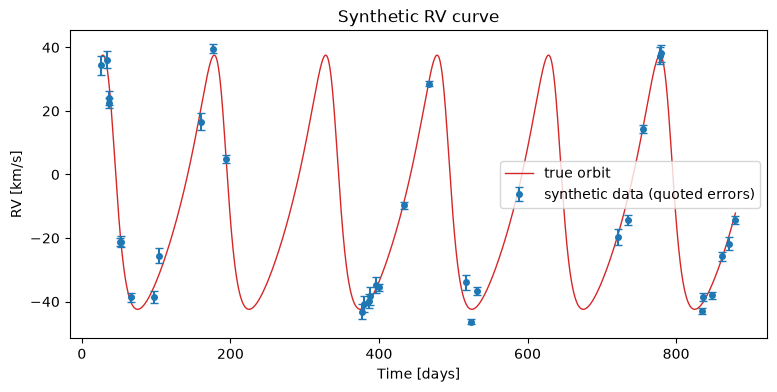

LS candidate periods: 151.0 d, 12.0 d, 240.2 d


You must install the tqdm library to use progress indicators with emcee


ML best:      ln L = -81.32 at P = 150.634 d
ML runner-up: ln L = -100.99 at P = 152.711 d (Delta ln L = 19.68)
tau = [75.2 76.5 74.4 73.5 75.7 76.3 72.9] | chain = 130.7 max-tau long (want > 50)
burn = 382, thin = 38, 16192 samples kept


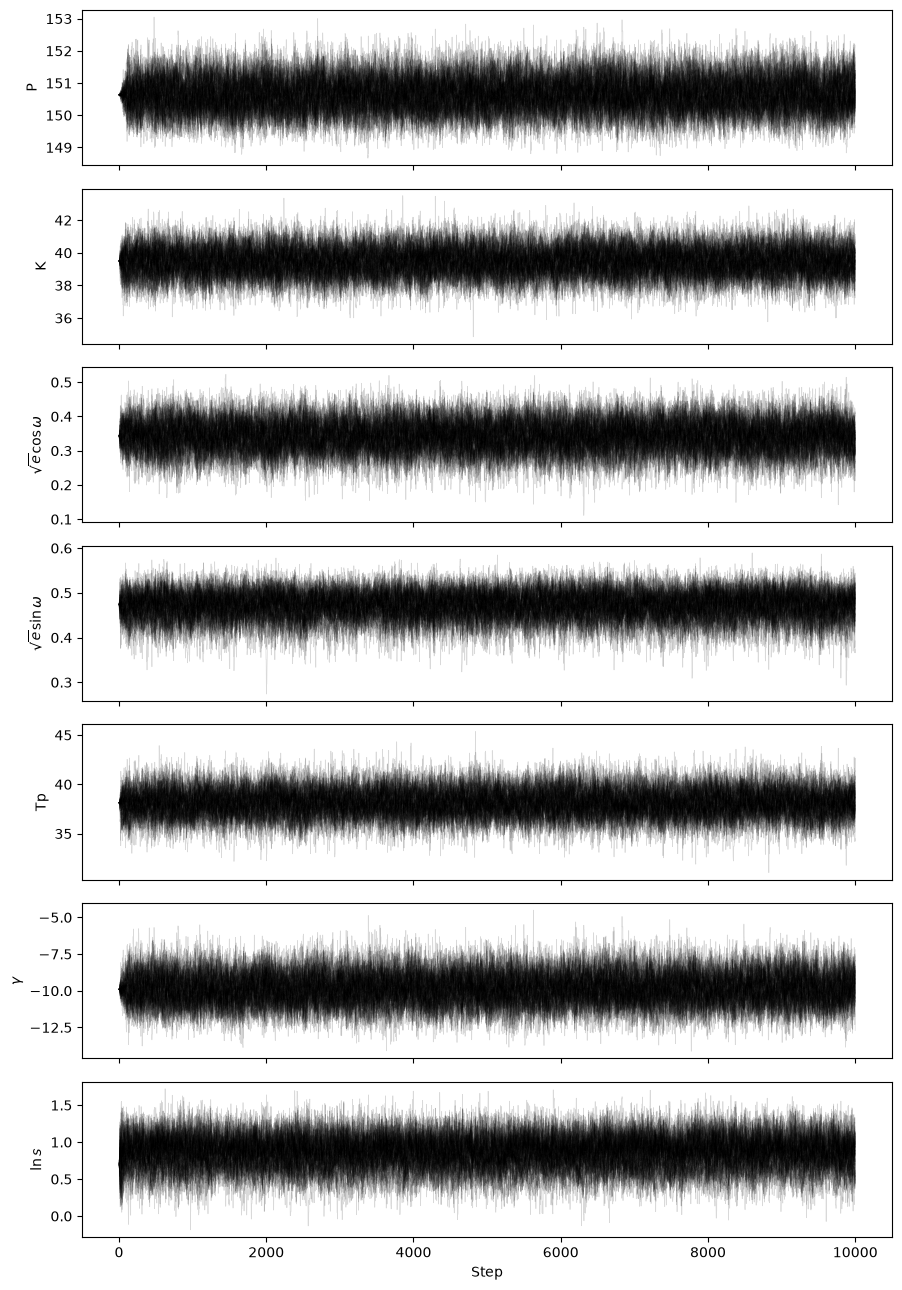


param              truth    center     +err     -err   summary  inside    pull
P [d]           150.0000  150.6445   0.4813   0.4813       std   False   -1.34
K [km/s]         40.0000   39.4754   0.7770   0.7770       std    True    0.68
e                 0.3500    0.3429   0.0196   0.0196       std    True    0.36
omega [rad]       1.0000    0.9436   0.0807   0.0807       std    True    0.70
Tp [d]           40.0000   38.1272   1.2517   1.2517       std   False    1.50
gamma [km/s]    -10.0000   -9.8643   0.9729   0.9729       std    True   -0.14
s [km/s]          3.0000    2.3288   0.5118   0.4248       pct   False    1.31
f(M) [Msun]       0.8176    0.7948   0.0482   0.0482       std    True    0.47

4 of 7 sampled parameters inside their interval (f(M) is derived, listed separately)


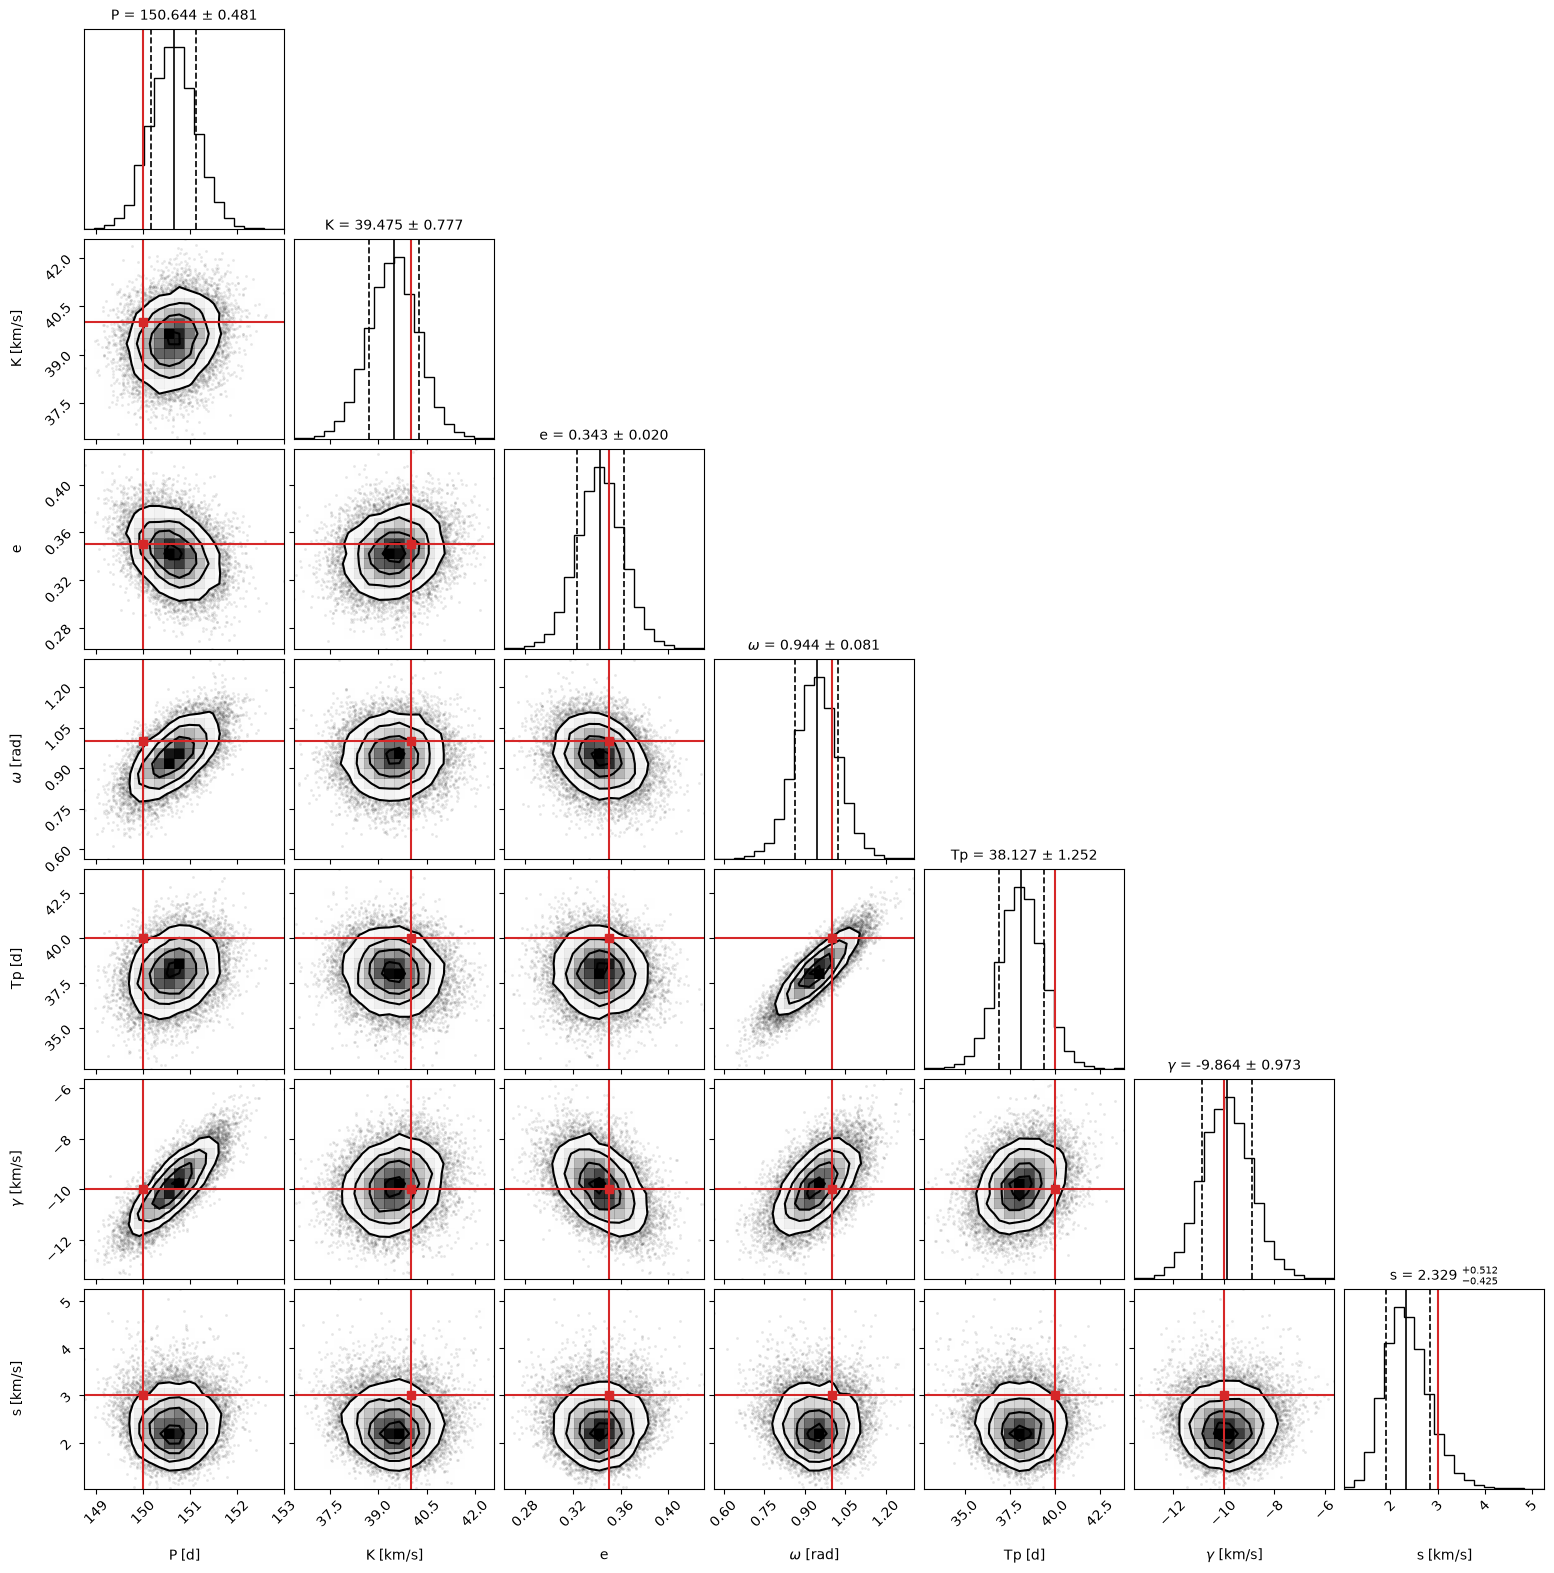


param            quantile of truth
P [d]                        0.089
K [km/s]                     0.756
e                            0.644
omega [rad]                  0.761
Tp [d]                       0.934
gamma [km/s]                 0.445
s [km/s]                     0.901
f(M) [Msun]                  0.681


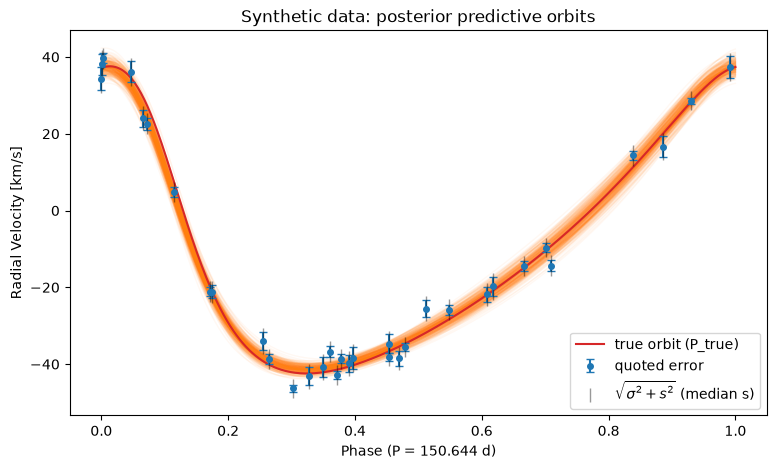

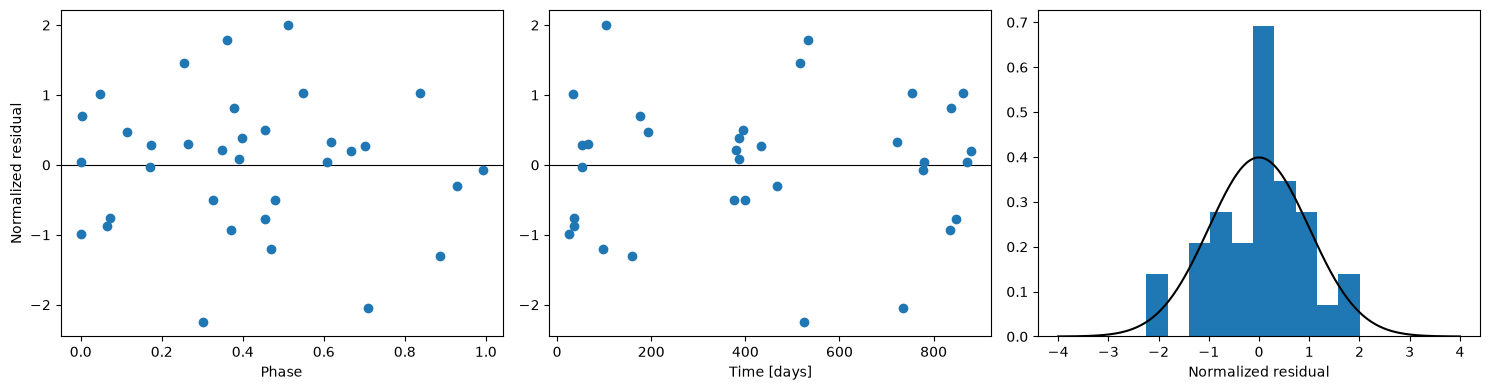

Synthetic normalized residuals: mean = 0.01, std = 0.98, chi2/N = 0.93


In [5]:
# =====================================================================
# 1. Synthetic dataset at YOUR epochs and YOUR quoted errors
# =====================================================================
SEED = 321
rng_syn = np.random.default_rng(SEED)

truth = dict(P=150.0, K=40.0, e=0.35, omega=1.0, Tp=40.0, gamma=-10.0, s=3.0)
truth['fM'] = mass_function(truth['P'], truth['K'], truth['e'])

t_syn = t.copy()                      # your real epochs
sig_syn = sig.copy()                  # your real quoted errors
model_true = kepler_rv(t_syn, truth['P'], truth['K'], truth['e'], truth['omega'], truth['Tp'], truth['gamma'])
rv_syn = model_true + rng_syn.normal(0., np.sqrt(sig_syn**2 + truth['s']**2))   # quoted error + jitter

print('Truth:', {k: round(v, 4) for k, v in truth.items()})

tt = np.linspace(t_syn.min(), t_syn.max(), 2000)
plt.figure(figsize=(9, 4))
plt.plot(tt, kepler_rv(tt, truth['P'], truth['K'], truth['e'], truth['omega'], truth['Tp'], truth['gamma']),
         'C3', lw=1, label='true orbit')
plt.errorbar(t_syn, rv_syn, yerr=sig_syn, fmt='o', ms=4, capsize=3, label='synthetic data (quoted errors)')
plt.xlabel('Time [days]'); plt.ylabel('RV [km/s]'); plt.legend(); plt.title('Synthetic RV curve')
plt.show()

# =====================================================================
# 2. The full Part 2 pipeline as one function (no dependence on globals)
# =====================================================================
def run_pipeline(t, rv, sig, nwalkers=64, nsteps=10000, seed=SEED, n_candidates=3):
    ndim = 7
    T = t.max() - t.min()

    # --- Part 1: Lomb-Scargle candidates ---
    freq = np.arange(1/1000, 1/5, 1/(10*T))
    pw = LombScargle(t, rv, sig).power(freq)
    pk, _ = find_peaks(pw)
    top = pk[np.argsort(pw[pk])[::-1][:n_candidates]]
    cand_ps = 1. / freq[top]
    print('LS candidate periods:', ', '.join(f'{p:.1f} d' for p in cand_ps))

    # --- model pieces (theta = [P, K, sqrt(e)cos w, sqrt(e)sin w, Tp, gamma, ln s]) ---
    win = dict(P_ref=None, Tp_ref=None)

    def unpack_(th):
        P, K, sc, ss, Tp, gam, lns = th
        return P, K, sc**2 + ss**2, np.arctan2(ss, sc), Tp, gam, np.exp(lns)

    def in_bounds_(th, check_Tp=True):
        P, K, sc, ss, Tp, gam, lns = th
        ok = (5. < P < 1000.) and (0. < K < 300.) and (sc**2 + ss**2 < 0.99) \
             and (-200. < gam < 200.) and (-7. < lns < 4.)
        if check_Tp and win['Tp_ref'] is not None:
            ok = ok and abs(Tp - win['Tp_ref']) < 0.5 * win['P_ref']
        return ok

    def loglike_(th):
        P, K, e, om, Tp, gam, s = unpack_(th)
        var = sig**2 + s**2
        return -0.5 * np.sum((rv - kepler_rv(t, P, K, e, om, Tp, gam))**2 / var + np.log(2*np.pi*var))

    def logpost_(th):
        if not in_bounds_(th):
            return -np.inf
        ll = loglike_(th)
        return -np.log(th[0]) + ll if np.isfinite(ll) else -np.inf

    def negll_(th):
        if not in_bounds_(th, check_Tp=False):
            return 1e25
        ll = loglike_(th)
        return -ll if np.isfinite(ll) else 1e25

    # --- ML starts: each candidate period x 4 omegas x 4 Tp ---
    K0, gam0, e0 = np.ptp(rv)/2., np.mean(rv), 0.3
    fits = []
    for P0 in cand_ps:
        P0 = float(P0)
        for om in np.linspace(0, 2*np.pi, 4, endpoint=False):
            for Tp0 in t.min() + np.linspace(0, 1, 4, endpoint=False) * P0:
                x0 = np.array([P0, K0, np.sqrt(e0)*np.cos(om), np.sqrt(e0)*np.sin(om), Tp0, gam0, 0.0])
                opts = dict(maxiter=20000, maxfev=20000, xatol=1e-7, fatol=1e-9, adaptive=True)
                res = minimize(negll_, x0, method='Nelder-Mead', options=opts)
                res = minimize(negll_, res.x, method='Nelder-Mead', options=opts)
                fits.append((-res.fun, P0, res.x))
    fits.sort(key=lambda f: f[0], reverse=True)
    best_ll, _, best_th = fits[0]
    runner = next((f for f in fits if abs(f[2][0] - best_th[0]) / best_th[0] > 0.01), None)
    print(f'ML best:      ln L = {best_ll:.2f} at P = {best_th[0]:.3f} d')
    if runner is not None:
        print(f'ML runner-up: ln L = {runner[0]:.2f} at P = {runner[2][0]:.3f} d '
              f'(Delta ln L = {best_ll - runner[0]:.2f})')

    win['P_ref'] = best_th[0]
    win['Tp_ref'] = t.min() + ((best_th[4] - t.min()) % best_th[0])
    best_th = best_th.copy(); best_th[4] = win['Tp_ref']

    # --- emcee ---
    rng_ = np.random.default_rng(seed)
    scl = np.array([1e-3, 1e-2, 1e-3, 1e-3, 1e-2, 1e-2, 1e-2])
    p0 = []
    while len(p0) < nwalkers:
        trial = best_th + scl * rng_.standard_normal(ndim)
        if np.isfinite(logpost_(trial)):
            p0.append(trial)
    smp = emcee.EnsembleSampler(nwalkers, ndim, logpost_)
    smp.run_mcmc(np.array(p0), nsteps, progress=True)

    tau_ = smp.get_autocorr_time(tol=0)
    print('tau =', np.round(tau_, 1), f'| chain = {nsteps/tau_.max():.1f} max-tau long (want > 50)')
    burn_, thin_ = int(5*tau_.max()), max(1, int(tau_.max()/2))
    fl = smp.get_chain(discard=burn_, thin=thin_, flat=True)
    flp = smp.get_log_prob(discard=burn_, thin=thin_, flat=True)
    print(f'burn = {burn_}, thin = {thin_}, {fl.shape[0]} samples kept')

    P_, K_, e_, om_, Tp_, gam_, s_ = unpack_(fl.T)
    out = dict(P=P_, K=K_, e=e_, omega=om_ % (2*np.pi), Tp=Tp_, gamma=gam_, s=s_,
               fM=mass_function(P_, K_, e_))          # per-sample f(M)
    return out, fl, flp, smp, tau_

# =====================================================================
# 3. Run it once on the synthetic data
# =====================================================================
post, fl_syn, flp_syn, smp_syn, tau_syn = run_pipeline(t_syn, rv_syn, sig_syn)

# chains
fig, axes = plt.subplots(7, 1, figsize=(9, 13), sharex=True)
for i, nm in enumerate(['P', 'K', r'$\sqrt{e}\cos\omega$', r'$\sqrt{e}\sin\omega$', 'Tp', r'$\gamma$', r'$\ln s$']):
    axes[i].plot(smp_syn.get_chain()[:, :, i], 'k', alpha=0.15, lw=0.5); axes[i].set_ylabel(nm)
axes[-1].set_xlabel('Step'); plt.tight_layout(); plt.show()

# =====================================================================
# 4. Compare the intervals to the truth
#    (mean +/- std, except PCT_PARAMS which use median + 16/84 percentiles)
#    omega is an angle and Tp is defined mod P, so wrap those samples onto the
#    branch nearest the truth first.
# =====================================================================
cmp = {k: post[k].copy() for k in post}
cmp['omega'] = truth['omega'] + ((post['omega'] - truth['omega'] + np.pi) % (2*np.pi) - np.pi)
P_med = np.median(post['P'])
cmp['Tp'] = truth['Tp'] + ((post['Tp'] - truth['Tp'] + P_med/2) % P_med - P_med/2)

rows = [('P [d]', 'P'), ('K [km/s]', 'K'), ('e', 'e'), ('omega [rad]', 'omega'),
        ('Tp [d]', 'Tp'), ('gamma [km/s]', 'gamma'), ('s [km/s]', 's'), ('f(M) [Msun]', 'fM')]

print(f'\n{"param":14s}{"truth":>10s}{"center":>10s}{"+err":>9s}{"-err":>9s}{"summary":>10s}{"inside":>8s}{"pull":>8s}')
n_in7 = 0
for lab, k in rows:
    c, lo_e, hi_e = summarize_param(cmp[k], k)
    inside = (c - lo_e) <= truth[k] <= (c + hi_e)
    pull = (truth[k] - c) / (hi_e if truth[k] > c else lo_e)
    kind = 'pct' if k in PCT_PARAMS else 'std'
    if k != 'fM':
        n_in7 += inside
    print(f'{lab:14s}{truth[k]:10.4f}{c:10.4f}{hi_e:9.4f}{lo_e:9.4f}{kind:>10s}{str(inside):>8s}{pull:8.2f}')
print(f'\n{n_in7} of 7 sampled parameters inside their interval (f(M) is derived, listed separately)')

# corner plot with the truth marked
keys7 = ['P', 'K', 'e', 'omega', 'Tp', 'gamma', 's']
phys_s = np.column_stack([cmp[k] for k in keys7])
corner_mixed(phys_s, ['P [d]', 'K [km/s]', 'e', r'$\omega$ [rad]', 'Tp [d]', r'$\gamma$ [km/s]', 's [km/s]'],
             keys7, truths=[truth[k] for k in keys7])
plt.show()

# =====================================================================
# 5. Where does the truth fall in each posterior? (should be ~uniform on [0,1])
# =====================================================================
print(f'\n{"param":14s}{"quantile of truth":>20s}')
for lab, k in rows:
    q = np.mean(cmp[k] < truth[k])
    print(f'{lab:14s}{q:20.3f}')

# =====================================================================
# 6. Posterior predictive check on the synthetic data
# =====================================================================
def unpack_syn(th):
    P, K, sc, ss, Tp, gam, lns = th
    return P, K, sc**2 + ss**2, np.arctan2(ss, sc), Tp, gam, np.exp(lns)

rng_pp = np.random.default_rng(SEED)
P_med = np.median(post['P'])
t0 = t_syn.min()                                   # fold reference (Tp window is anchored near t.min())
phase_data = ((t_syn - t0) / P_med) % 1.0
phase_grid = np.linspace(0, 1, 400)
t_grid = t0 + phase_grid * P_med

fig, ax = plt.subplots(figsize=(9, 5))
idx = rng_pp.choice(fl_syn.shape[0], size=300, replace=False)
for j in idx:
    P_, K_, e_, om_, Tp_, g_, s_ = unpack_syn(fl_syn[j])
    ax.plot(phase_grid, kepler_rv(t_grid, P_, K_, e_, om_, Tp_, g_), color='C1', alpha=0.05, lw=1)

# true orbit, folded the same way
ax.plot(phase_grid, kepler_rv(t_grid, truth['P'], truth['K'], truth['e'], truth['omega'],
                              truth['Tp'], truth['gamma']), 'C3', lw=1.5, label='true orbit (P_true)')
tot_err = np.sqrt(sig_syn**2 + np.median(post['s'])**2)
ax.errorbar(phase_data, rv_syn, yerr=sig_syn, fmt='o', color='C0', ms=4, capsize=3, elinewidth=1.5,
            label='quoted error')
ax.errorbar(phase_data, rv_syn, yerr=tot_err, fmt='none', ecolor='k', alpha=0.4, elinewidth=1,
            label=r'$\sqrt{\sigma^2+s^2}$ (median s)')
ax.set_xlabel(f'Phase (P = {P_med:.3f} d)'); ax.set_ylabel('Radial Velocity [km/s]')
ax.set_title('Synthetic data: posterior predictive orbits'); ax.legend()
plt.show()

# =====================================================================
# 7. Normalized residuals (about the max-posterior sample, total error)
# =====================================================================
imap = np.argmax(flp_syn)
P_, K_, e_, om_, Tp_, g_, s_ = unpack_syn(fl_syn[imap])
model_map = kepler_rv(t_syn, P_, K_, e_, om_, Tp_, g_)
resid_syn = (rv_syn - model_map) / np.sqrt(sig_syn**2 + s_**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].axhline(0, color='k', lw=0.8)
axes[0].plot(phase_data, resid_syn, 'o'); axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Normalized residual')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].plot(t_syn, resid_syn, 'o'); axes[1].set_xlabel('Time [days]')
axes[2].hist(resid_syn, bins=10, density=True)
xx = np.linspace(-4, 4, 200)
axes[2].plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), 'k')
axes[2].set_xlabel('Normalized residual')
plt.tight_layout(); plt.show()
print(f'Synthetic normalized residuals: mean = {resid_syn.mean():.2f}, '
      f'std = {resid_syn.std(ddof=1):.2f}, chi2/N = {np.mean(resid_syn**2):.2f}')